### Closing price prediction of a stock using data from the last 60 days via LSTM

In [44]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import time
from math import sqrt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.callbacks import ModelCheckpoint
import tensorflow.keras.backend as K

In [45]:
start_time = time.time()

In [46]:
# Load data
df = pd.read_csv('../Download data/data.csv', index_col=0, parse_dates=True)

# Display data
df

,close
date,
2015-01-02,205.43
2015-01-05,201.72
2015-01-06,199.82
2015-01-07,202.31
2015-01-08,205.90
...,...
2024-12-24,601.30
2024-12-26,601.34
2024-12-27,595.01


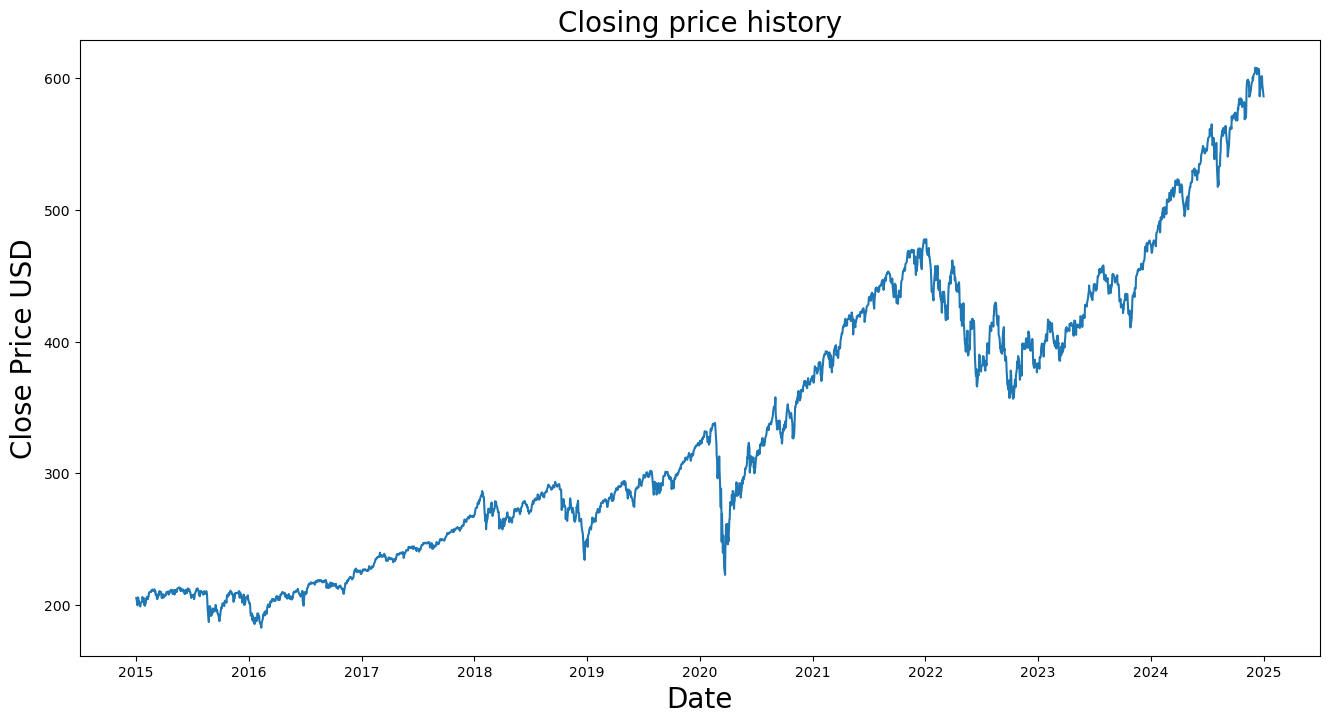

In [47]:
# Display closing price history
plt.figure(figsize=(16,8))
plt.title('Closing price history', fontsize=20)
plt.plot(df['close'])
plt.xlabel('Date',fontsize=20)
plt.ylabel('Close Price USD', fontsize=20)
plt.show()

In [48]:
# Extract 'Close' prices as Dataframe
data = df[['close']].copy()

In [49]:
# Scale data between 0 and 1
scaler = MinMaxScaler((0,1))
data_scaled = scaler.fit_transform(data)

data_scaled

array([[0.05311213],
       [0.04438169],
       [0.03991058],
       ...,
       [0.96987881],
       [0.95390046],
       [0.94886457]])

In [50]:
# Create sliding windows seqences
window = 60
x = []
y = []

for i in range(window, len(data_scaled)):
    x.append(data_scaled[i - window:i, 0])
    y.append(data_scaled[i, 0])

x = np.array(x)
y = np.array(y)
x = x.reshape((x.shape[0], x.shape[1], 1))

In [51]:
# Split training and test sets
train_size = int(len(x) * 0.8)
x_train, x_test = x[:train_size], x[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [52]:
# Batch sizes for testing
batch_sizes = [4, 8, 16, 32]
rmse_scores, mae_scores, r2_scores, model_paths = {}, {}, {}, {}

In [53]:
# Add RMSE metric for ModelCheckpoint
def root_mean_squared_error(y_true, y_pred):
    return K.sqrt(K.mean(K.square(y_pred - y_true)))

In [54]:
# Building the LSTM model
def build_model():
    model = Sequential([
        Input(shape=(x_train.shape[1], 1)),
        LSTM(60, return_sequences=True),
        LSTM(40, return_sequences=False),
        Dense(30),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=[root_mean_squared_error])
    return model

In [55]:
# Preserve date index for plotting
valid = data[-len(y_test):].copy()

In [56]:
# --- Utility Functions ---
def evaluate_model(y_true, y_pred, batch_size):
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rmse = sqrt(mean_squared_error(y_true, y_pred))
    
    print(f"Batch size {batch_size} evaluation:")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  R²:   {r2:.4f}")
    
    return rmse, mae, r2

def plot_predictions(y_true, y_pred, batch_size):
    plt.figure(figsize=(8, 4))
    plt.plot(y_true, label='Real values')
    plt.plot(y_pred, label='Predicted values')
    plt.title(f'Comparison between actual and predicted values - Batch size: ({batch_size})')
    plt.xlabel('Date (Daily Index)')
    plt.xticks(
        ticks=np.linspace(0, len(valid.index)-1, 10, dtype=int),
        labels=[valid.index[i].strftime('%Y-%m-%d') for i in np.linspace(0, len(valid.index)-1, 10, dtype=int)],
        rotation=45
    )
    plt.ylabel('Close Price USD')
    plt.legend()
    plt.show()

def display_comparison(y_true, y_pred):
    comparison_df = pd.DataFrame({
        'Acutal values': y_true.flatten(),
        'Predicted values': y_pred.flatten()
    })
    print(comparison_df)


Training with batch size = 4
Batch size 4 evaluation:
  RMSE: 4.0284
  MAE:  3.1101
  R²:   0.9960


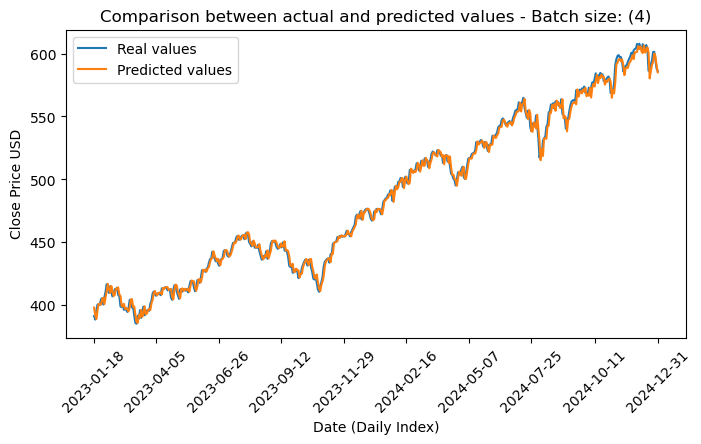

     Acutal values  Predicted values
0           391.49        398.203491
1           388.64        392.137817
2           395.88        389.141449
3           400.63        396.121277
4           400.20        401.227600
..             ...               ...
487         601.30        593.298279
488         601.34        600.033203
489         595.01        597.986084
490         588.22        590.869263
491         586.08        585.075562

[492 rows x 2 columns]

Training with batch size = 8
Batch size 8 evaluation:
  RMSE: 4.6767
  MAE:  3.5320
  R²:   0.9947


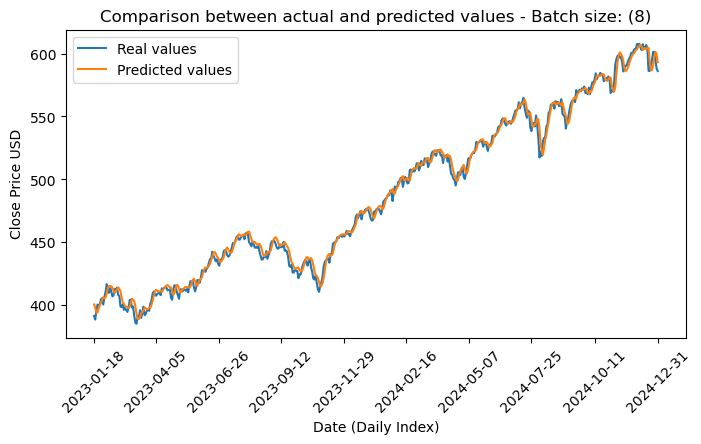

     Acutal values  Predicted values
0           391.49        400.672516
1           388.64        397.996063
2           395.88        394.146881
3           400.63        394.329102
4           400.20        397.475189
..             ...               ...
487         601.30        590.685486
488         601.34        597.310669
489         595.01        601.367798
490         588.22        599.331177
491         586.08        593.188049

[492 rows x 2 columns]

Training with batch size = 16
Batch size 16 evaluation:
  RMSE: 5.5617
  MAE:  4.2813
  R²:   0.9924


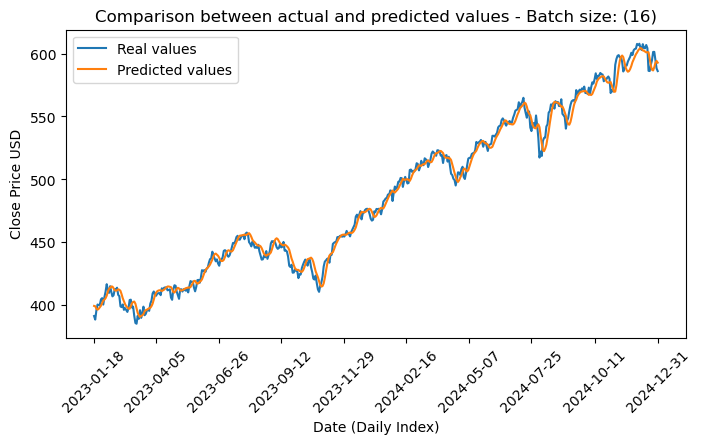

     Acutal values  Predicted values
0           391.49        399.502716
1           388.64        399.241455
2           395.88        397.356110
3           400.63        396.491913
4           400.20        397.188904
..             ...               ...
487         601.30        586.566040
488         601.34        589.165955
489         595.01        592.627930
490         588.22        594.123840
491         586.08        592.762695

[492 rows x 2 columns]

Training with batch size = 32
Batch size 32 evaluation:
  RMSE: 5.0050
  MAE:  3.9379
  R²:   0.9939


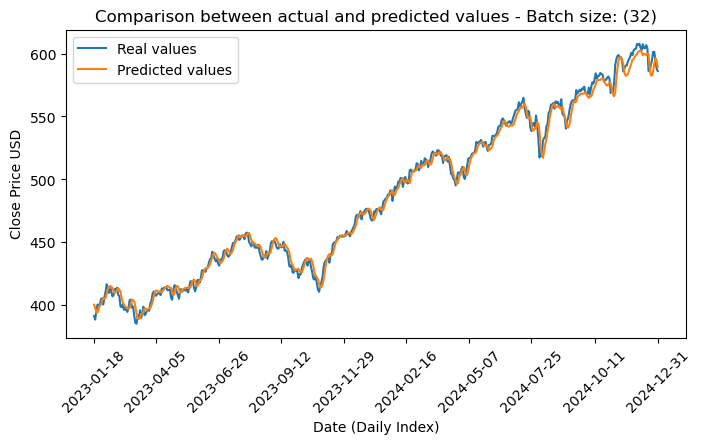

     Acutal values  Predicted values
0           391.49        400.471741
1           388.64        397.935669
2           395.88        394.192749
3           400.63        394.264496
4           400.20        397.097290
..             ...               ...
487         601.30        585.840820
488         601.34        592.119629
489         595.01        596.165100
490         588.22        594.565369
491         586.08        589.077820

[492 rows x 2 columns]


In [57]:
# Train model on each batch size
for batch_size in batch_sizes:
    print(f"\nTraining with batch size = {batch_size}")
    model = build_model()
    checkpoint_path = f"best_model_bs_{batch_size}.keras"
    checkpoint = ModelCheckpoint(
        checkpoint_path,
        monitor="val_root_mean_squared_error",
        save_best_only=True,
        mode="min",
        verbose=0
    )

    model.fit(
        x_train, y_train,
        validation_data=(x_test, y_test),
        epochs=100,
        batch_size=batch_size,
        callbacks=[checkpoint],
        verbose=0
    )

    best_model = load_model(checkpoint_path, custom_objects={'root_mean_squared_error': root_mean_squared_error})
    predictions = best_model.predict(x_test, verbose=0)
    predictions = scaler.inverse_transform(predictions)
    y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))

    # Evaluate & visualize
    rmse, mae, r2 = evaluate_model(y_test_rescaled, predictions, batch_size)
    rmse_scores[batch_size] = rmse
    mae_scores[batch_size] = mae
    r2_scores[batch_size] = r2
    model_paths[batch_size] = checkpoint_path

    plot_predictions(y_test_rescaled, predictions, batch_size)
    display_comparison(y_test_rescaled, predictions)

In [58]:
# Best batch size
best_batch = min(rmse_scores, key=rmse_scores.get)
print(f"\nBest batch size: {best_batch}")
print(f"RMSE: {rmse_scores[best_batch]:.4f}")
print(f"MAE:  {mae_scores[best_batch]:.4f}")
print(f"R²:   {r2_scores[best_batch]:.4f}")


Best batch size: 4
RMSE: 4.0284
MAE:  3.1101
R²:   0.9960


In [59]:
# Load the best model
best_model = load_model(model_paths[best_batch], custom_objects={'root_mean_squared_error': root_mean_squared_error})
predictions = best_model.predict(x_test, verbose=0)
predictions = scaler.inverse_transform(predictions)
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))

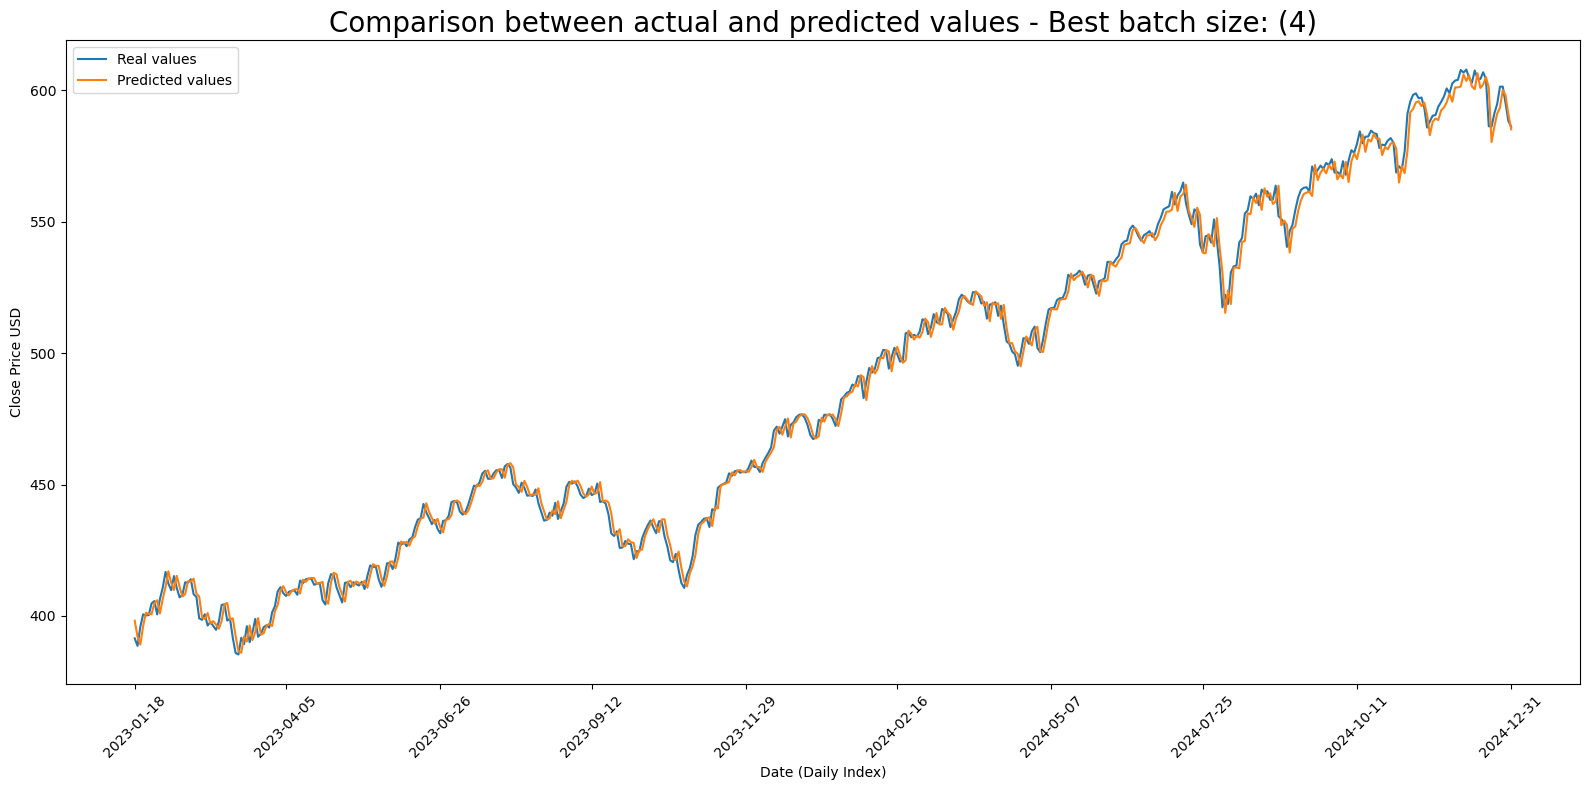

     Acutal values  Predicted values
0           391.49        398.203491
1           388.64        392.137817
2           395.88        389.141449
3           400.63        396.121277
4           400.20        401.227600
..             ...               ...
487         601.30        593.298279
488         601.34        600.033203
489         595.01        597.986084
490         588.22        590.869263
491         586.08        585.075562

[492 rows x 2 columns]


In [60]:
# Plot & display actual vs predicted values for the best batch size
plt.figure(figsize=(16, 8))
plt.plot(y_test_rescaled, label='Real values')
plt.plot(predictions, label='Predicted values')
plt.title(f'Comparison between actual and predicted values - Best batch size: ({best_batch})', fontsize=20)
plt.xlabel('Date (Daily Index)')
plt.xticks(
    ticks=np.linspace(0, len(valid.index)-1, 10, dtype=int),  
    labels=[valid.index[i].strftime('%Y-%m-%d') for i in np.linspace(0, len(valid.index)-1, 10, dtype=int)],
    rotation=45
)
plt.ylabel('Close Price USD')
plt.legend()
plt.tight_layout()
plt.show()

display_comparison(y_test_rescaled, predictions)

In [61]:
# Final results DataFrame for plotting
valid_index = df.index[-len(y_test):]  
results_df = pd.DataFrame({
    'Close': y_test_rescaled.flatten(),
    'Predictions': predictions.flatten()
}, index=valid_index)
train_index = df.index[:len(df) - len(y_test)]

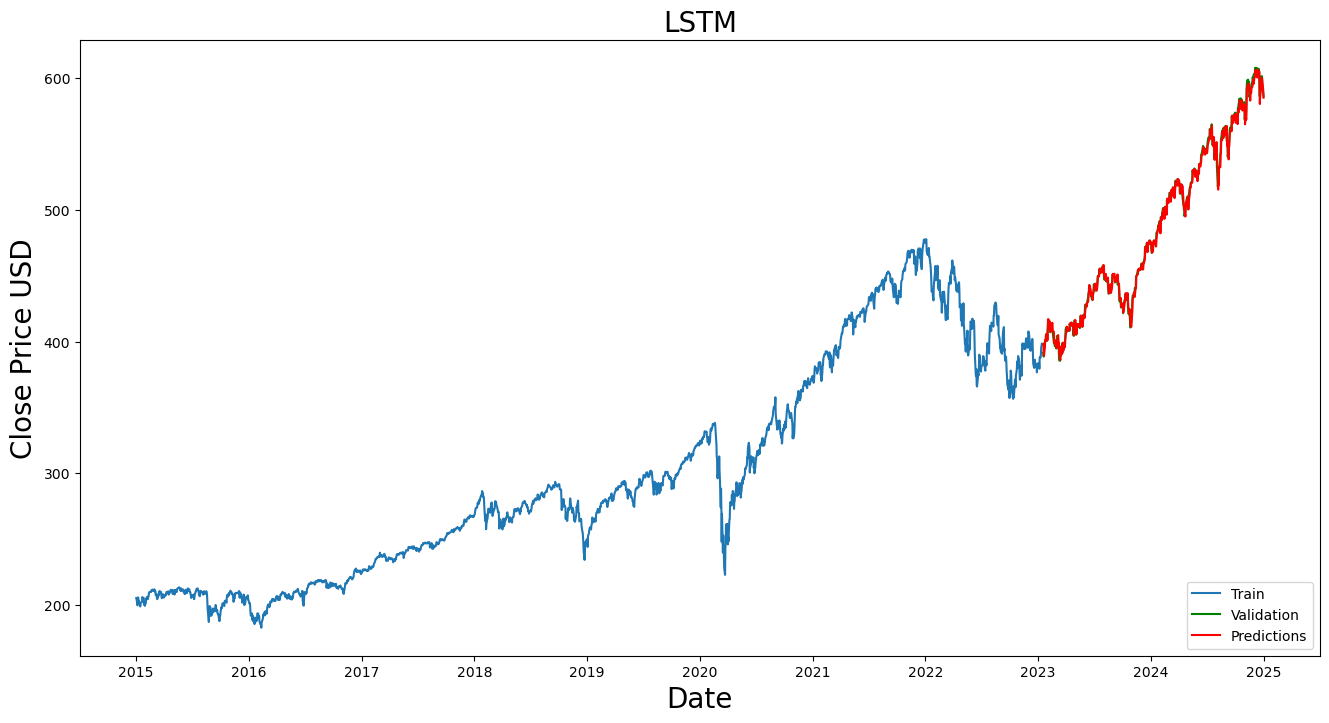

In [62]:
# Plot training, validation and predictions
plt.figure(figsize=(16, 8))
plt.title('LSTM', fontsize=20)
plt.xlabel('Date', fontsize=20)
plt.ylabel('Close Price USD', fontsize=20)
plt.plot(train_index, df.loc[train_index, 'close'], label='Train')
plt.plot(results_df.index, results_df['Close'], label='Validation', color='green')
plt.plot(results_df.index, results_df['Predictions'], label='Predictions', color='red')
plt.legend(loc='lower right')
plt.show()

In [63]:
end_time = time.time()
elapsed_time = end_time - start_time

print(f"Execution time: {elapsed_time:.2f} seconds")

Execution time: 1669.57 seconds
